# 02 — Model Training & Explainable AI (XAI)

**Objective:** Train two LightGBM classifiers on the NSL-KDD dataset —
1. **Model 1** predicts the *specific* attack type (23+ classes).
2. **Model 2** predicts the *5 main categories* (Normal, DoS, Probe, R2L, U2R).

Both models are evaluated with classification reports and confusion matrices.
Finally, SHAP (SHapley Additive exPlanations) is used to explain Model 2's predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import shap
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All imports loaded successfully.")

All imports loaded successfully.


/Users/omerahat/Desktop/EXID/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Load Processed Data

Load the feature matrices and target vectors saved by `01_EDA_Feature_Engineering.ipynb`.
The target dataframe (`y`) contains four columns:

| Column | Description |
|---|---|
| `class` | Original attack label (string) |
| `mapped_class` | 5-category label (string) |
| `class_encoded` | Integer-encoded specific attack |
| `mapped_class_encoded` | Integer-encoded 5-category (0–4, or −1 for unseen attacks) |

In [2]:
DATA_DIR = "../data/processed/"

X_train = pd.read_parquet(DATA_DIR + "X_train.parquet")
X_test  = pd.read_parquet(DATA_DIR + "X_test.parquet")
y_train = pd.read_parquet(DATA_DIR + "y_train.parquet")
y_test  = pd.read_parquet(DATA_DIR + "y_test.parquet")

# Drop metadata columns that should not be used as features
cols_to_drop = [c for c in ["difficulty"] if c in X_train.columns]
if cols_to_drop:
    X_train = X_train.drop(columns=cols_to_drop)
    X_test  = X_test.drop(columns=cols_to_drop)
    print(f"Dropped metadata columns: {cols_to_drop}")

# --- Targets for Model 1 (specific attack classes) ---
y_train_specific = y_train["class_encoded"]
y_test_specific  = y_test["class_encoded"]

# --- Targets for Model 2 (5 main categories) ---
# Filter out rows with mapped_class_encoded == -1 (unseen attack types in test)
y_train_mapped = y_train["mapped_class_encoded"]
y_test_mapped  = y_test["mapped_class_encoded"]

train_mask_valid = y_train_mapped != -1
test_mask_valid  = y_test_mapped  != -1

X_train_mapped = X_train[train_mask_valid].reset_index(drop=True)
y_train_mapped = y_train_mapped[train_mask_valid].reset_index(drop=True)

X_test_mapped = X_test[test_mask_valid].reset_index(drop=True)
y_test_mapped = y_test_mapped[test_mask_valid].reset_index(drop=True)

# Category name mapping for display
CATEGORY_NAMES = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
CATEGORY_LIST  = [CATEGORY_NAMES[i] for i in range(5)]

print(f"X_train:        {X_train.shape}  |  y_train_specific: {y_train_specific.shape}")
print(f"X_test:         {X_test.shape}  |  y_test_specific:  {y_test_specific.shape}")
print(f"X_train_mapped: {X_train_mapped.shape}  |  y_train_mapped:   {y_train_mapped.shape}")
print(f"X_test_mapped:  {X_test_mapped.shape}  |  y_test_mapped:    {y_test_mapped.shape}")
print(f"\nFiltered out {(~test_mask_valid).sum()} test rows with unknown category (mapped_class_encoded == -1)")

Dropped metadata columns: ['difficulty']
X_train:        (125972, 109)  |  y_train_specific: (125972,)
X_test:         (22544, 109)  |  y_test_specific:  (22544,)
X_train_mapped: (125972, 109)  |  y_train_mapped:   (125972,)
X_test_mapped:  (18794, 109)  |  y_test_mapped:    (18794,)

Filtered out 3750 test rows with unknown category (mapped_class_encoded == -1)


## 2 — Model 1: Specific Attack Classification

A LightGBM classifier trained to distinguish all individual attack types present in the NSL-KDD dataset.
`class_weight='balanced'` compensates for the severe class imbalance across rare attacks like *spy*, *perl*, and *loadmodule*.

In [3]:
model_specific = lgb.LGBMClassifier(
    objective="multiclass",
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_specific.fit(X_train, y_train_specific)
print(f"Model 1 trained — {model_specific.n_classes_} classes detected.")

Model 1 trained — 23 classes detected.


## 3 — Model 2: 5-Category Classification

A second LightGBM classifier that groups attacks into five high-level categories:
**Normal, DoS, Probe, R2L, U2R**.

Rows with `mapped_class_encoded == -1` (attack types in the test set that have no category mapping) are excluded from both training and evaluation.

In [4]:
model_mapped = lgb.LGBMClassifier(
    objective="multiclass",
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_mapped.fit(X_train_mapped, y_train_mapped)
print(f"Model 2 trained — {model_mapped.n_classes_} categories: {CATEGORY_LIST}")

Model 2 trained — 5 categories: ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']


## 4 — Model Evaluation

### 4.1 Model 1 — Specific Attack Classification Report

In [5]:
y_pred_specific = model_specific.predict(X_test)

print("=" * 72)
print("MODEL 1 — Specific Attack Classification Report")
print("=" * 72)
print(classification_report(y_test_specific, y_pred_specific, zero_division=0))

MODEL 1 — Specific Attack Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.48      0.38      0.43       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       1.00      0.03      0.06      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.99      0.99      0.99       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94      1.00      0.97      4657
          15       0.43      1.00      0.61        73
          16       0.65      0.97

### 4.2 Model 1 — Confusion Matrix

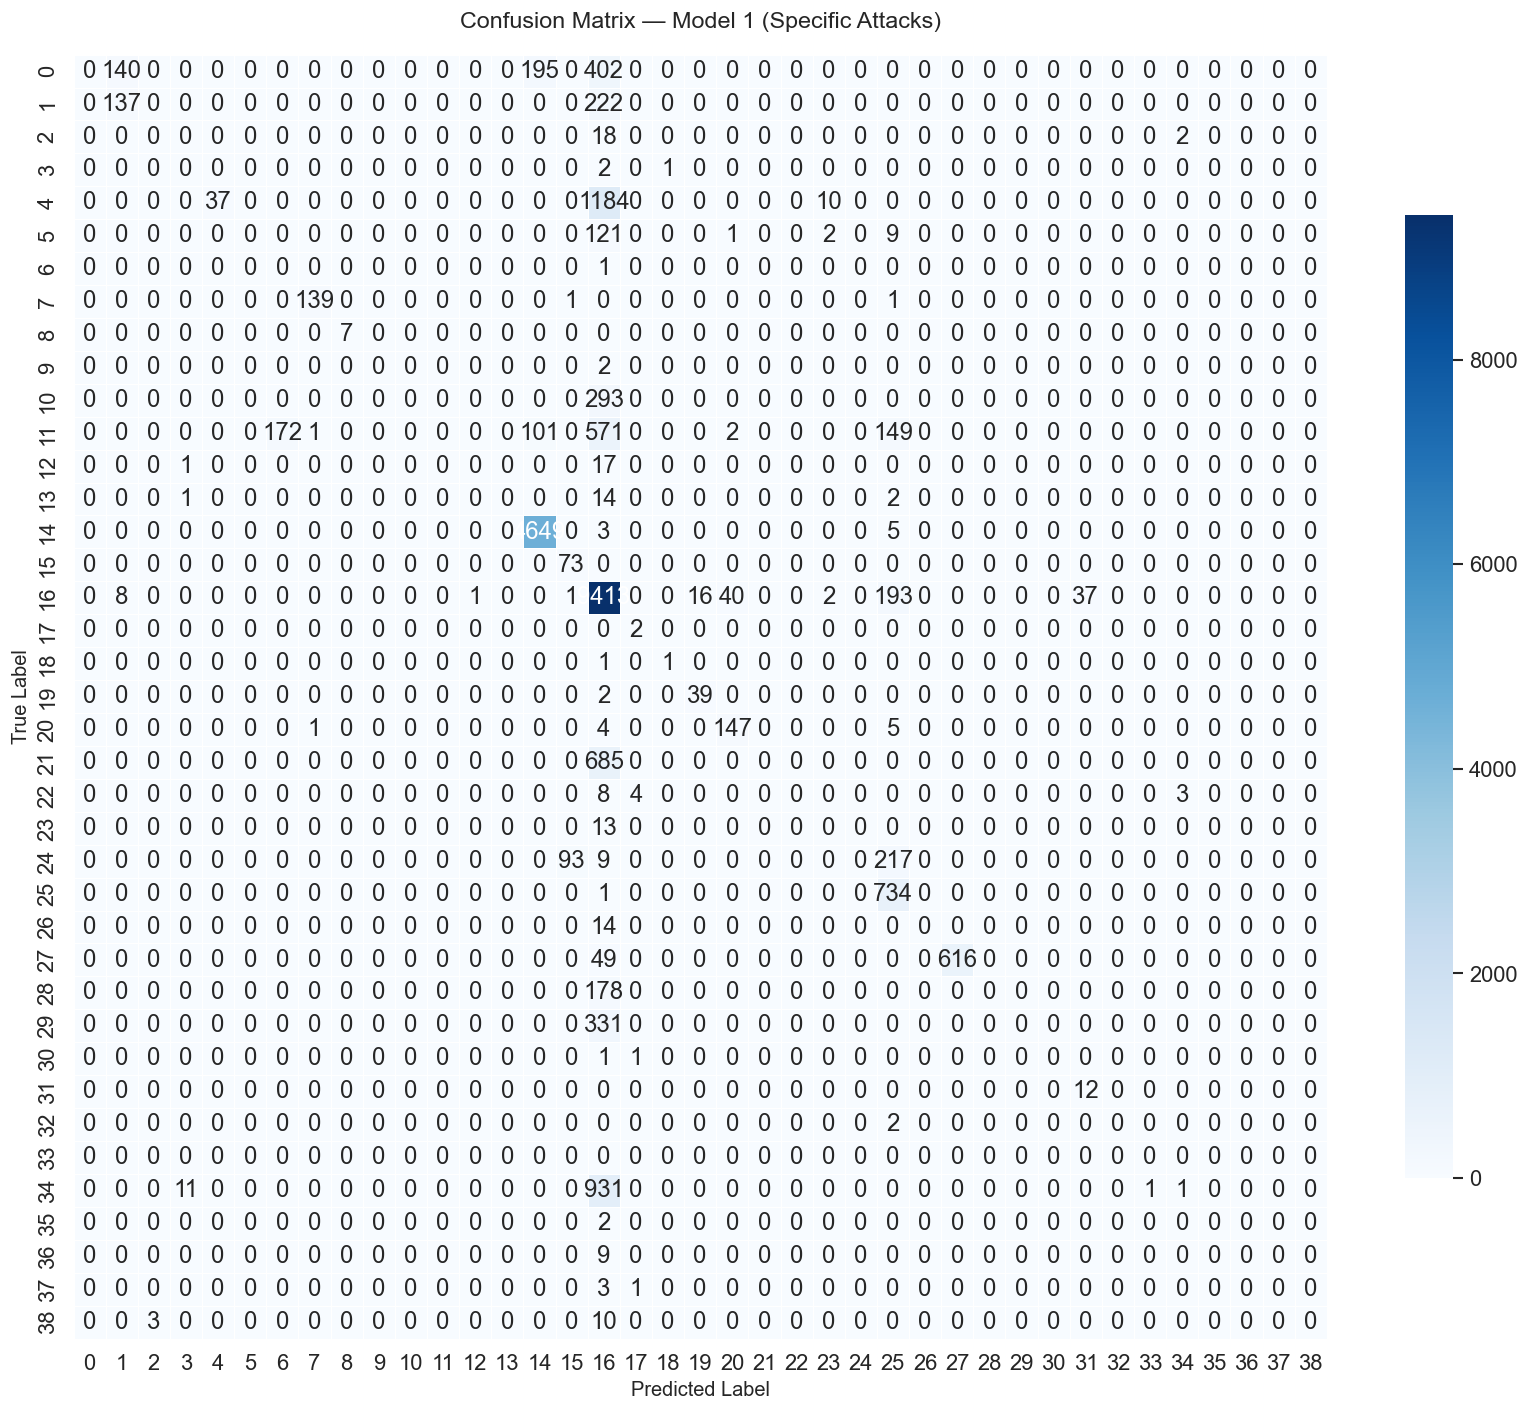

In [6]:
cm_specific = confusion_matrix(y_test_specific, y_pred_specific)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_specific,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Confusion Matrix — Model 1 (Specific Attacks)", pad=16)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

### 4.3 Model 2 — 5-Category Classification Report

In [7]:
y_pred_mapped = model_mapped.predict(X_test_mapped)

print("=" * 72)
print("MODEL 2 — 5-Category Classification Report")
print("=" * 72)
print(classification_report(
    y_test_mapped,
    y_pred_mapped,
    target_names=CATEGORY_LIST,
    zero_division=0,
))

MODEL 2 — 5-Category Classification Report
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.88      9711
         DoS       0.99      0.96      0.97      5741
       Probe       0.81      1.00      0.90      1106
         R2L       0.99      0.13      0.23      2199
         U2R       0.62      0.22      0.32        37

    accuracy                           0.87     18794
   macro avg       0.84      0.66      0.66     18794
weighted avg       0.89      0.87      0.84     18794



### 4.4 Model 2 — Confusion Matrix

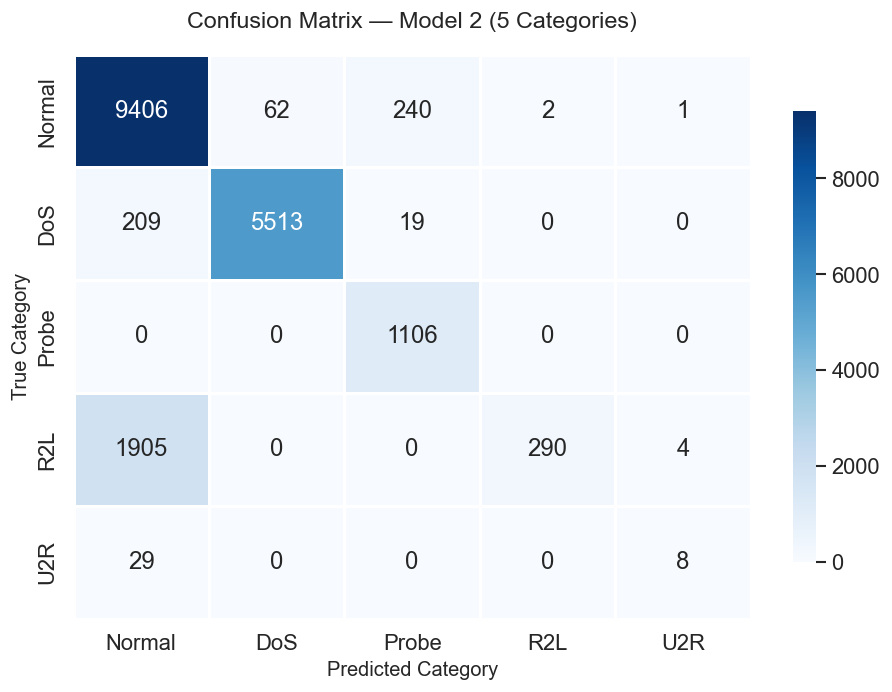

In [8]:
cm_mapped = confusion_matrix(y_test_mapped, y_pred_mapped)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_mapped,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORY_LIST,
    yticklabels=CATEGORY_LIST,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Confusion Matrix — Model 2 (5 Categories)", pad=16)
ax.set_xlabel("Predicted Category")
ax.set_ylabel("True Category")
plt.tight_layout()
plt.show()

## 5 — Explainable AI with SHAP

SHAP (SHapley Additive exPlanations) assigns each feature an importance value for every prediction.
We use `TreeExplainer` — optimised for tree-based models like LightGBM — on **Model 2** (the 5-category classifier) to understand which network-traffic features drive each category's predictions.

A random sample of **1 000** test instances is used to keep computation time manageable.

In [9]:
SHAP_SAMPLE_SIZE = 1000

np.random.seed(42)
sample_idx = np.random.choice(
    X_test_mapped.shape[0], size=SHAP_SAMPLE_SIZE, replace=False
)
X_sample = X_test_mapped.iloc[sample_idx]

explainer = shap.TreeExplainer(model_mapped)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {SHAP_SAMPLE_SIZE} samples.")
print(f"Shape per class: {shap_values[0].shape}  |  Number of classes: {len(shap_values)}")

SHAP values computed for 1000 samples.
Shape per class: (109, 5)  |  Number of classes: 1000


### 5.1 SHAP Summary Plot

Each row is a feature; each dot is a single test sample. The colour shows the feature value (red = high, blue = low) and the horizontal position shows the SHAP impact on the model output for each class.

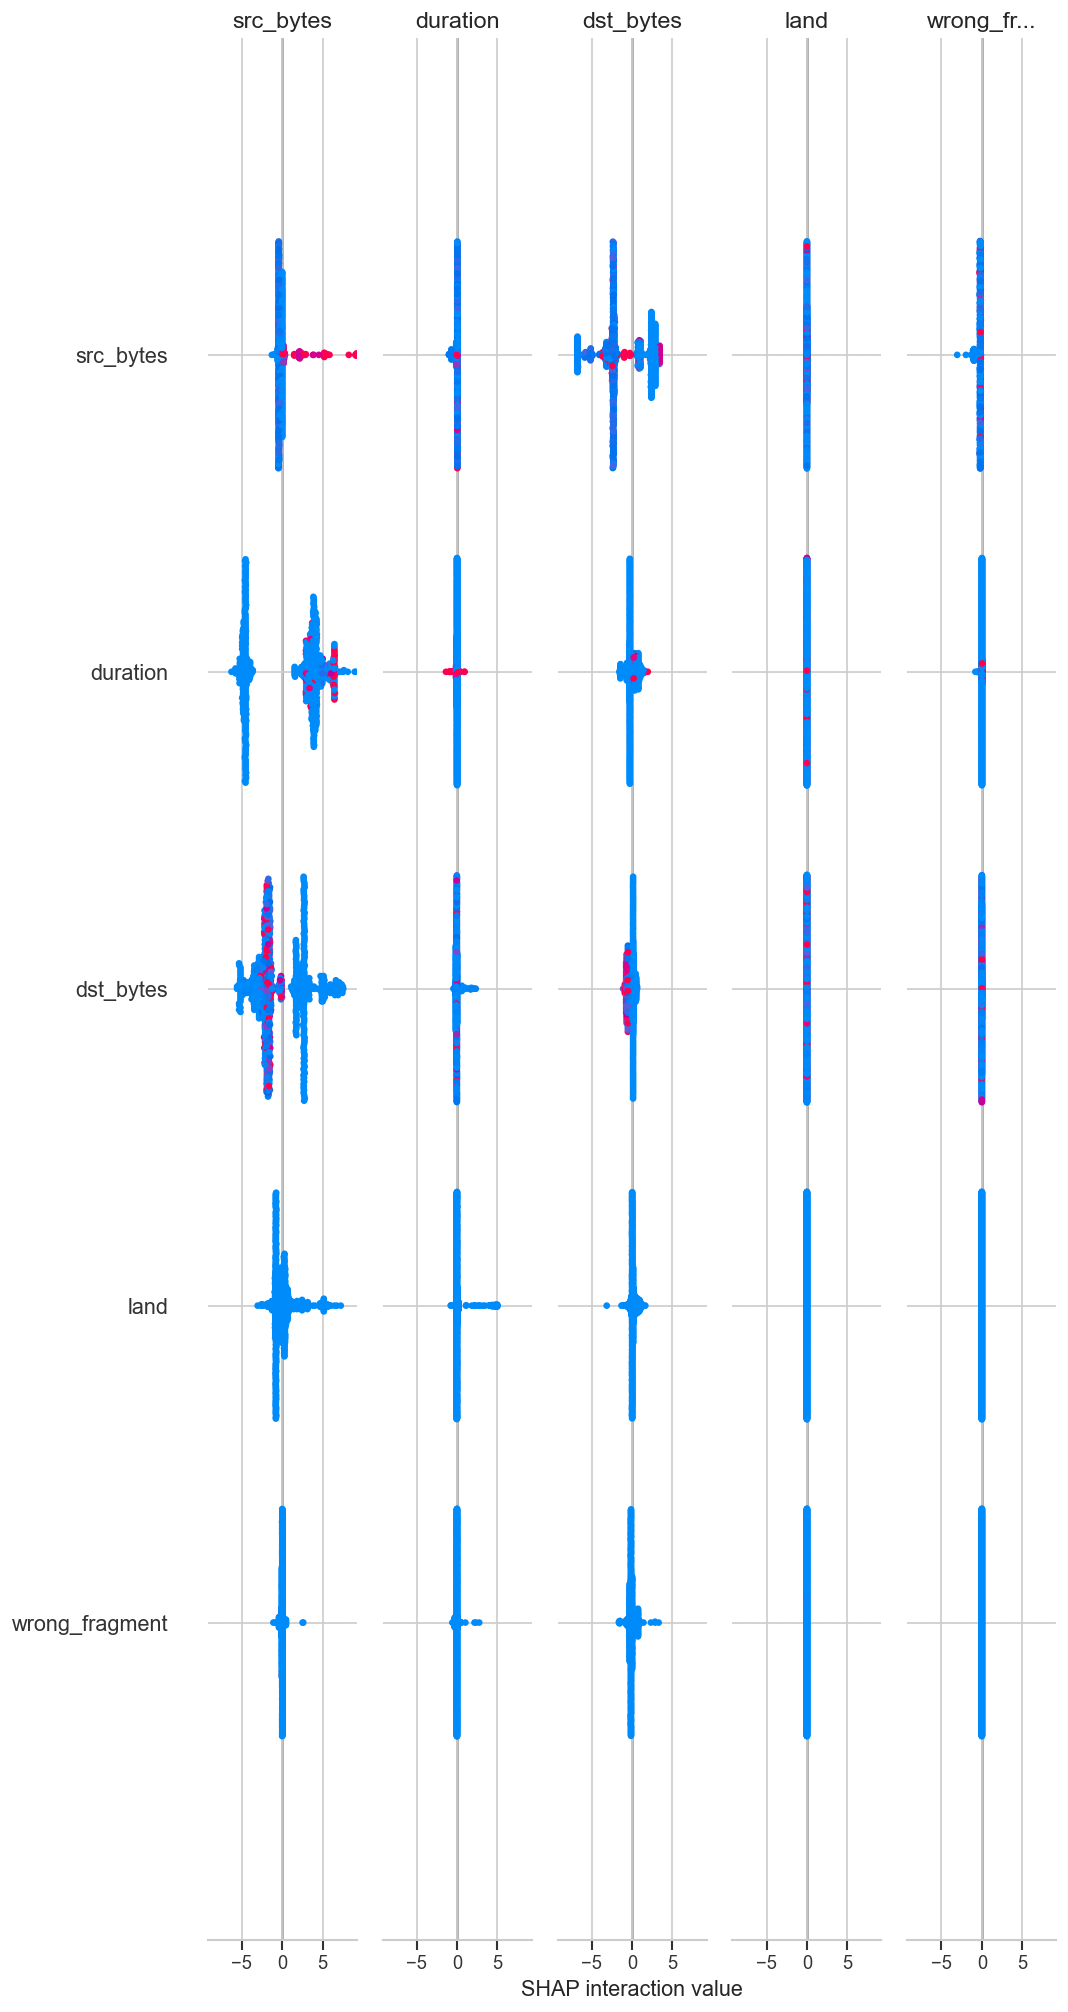

In [10]:
shap.summary_plot(
    shap_values,
    X_sample,
    class_names=CATEGORY_LIST,
    show=False,
    max_display=20,
)
plt.tight_layout()
plt.show()